# Credit Card Fraud Detection

## 1. Import Libraries and Modules

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer

## 2. Load the Dataset

In [2]:
df = pd.read_csv("../data/credit_card_fraud_10k.csv")

In [3]:
df.head()

,transaction_id,amount,transaction_hour,merchant_category,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,is_fraud
0,1,84.47,22,Electronics,0,0,66,3,40,0
1,2,541.82,3,Travel,1,0,87,1,64,0
2,3,237.01,17,Grocery,0,0,49,1,61,0
3,4,164.33,4,Grocery,0,1,72,3,34,0
4,5,30.53,15,Food,0,0,79,0,44,0


## 3. Basic Dataset Understanding

In [4]:
print("Shape:")
print(df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

Shape:
(10000, 10)

Columns:
['transaction_id', 'amount', 'transaction_hour', 'merchant_category', 'foreign_transaction', 'location_mismatch', 'device_trust_score', 'velocity_last_24h', 'cardholder_age', 'is_fraud']

Data Types:
transaction_id           int64
amount                 float64
transaction_hour         int64
merchant_category       object
foreign_transaction      int64
location_mismatch        int64
device_trust_score       int64
velocity_last_24h        int64
cardholder_age           int64
is_fraud                 int64
dtype: object


In [34]:
df.describe()

,transaction_id,amount,transaction_hour,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,is_fraud
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5000.50000,175.949849,11.593300,0.097800,0.085700,61.798900,2.008900,43.468700,0.015100
std,2886.89568,175.392827,6.922708,0.297059,0.279935,21.487053,1.432559,14.979147,0.121957
min,1.00000,0.000000,0.000000,0.000000,0.000000,25.000000,0.000000,18.000000,0.000000
25%,2500.75000,50.905000,6.000000,0.000000,0.000000,43.000000,1.000000,30.000000,0.000000
50%,5000.50000,122.095000,12.000000,0.000000,0.000000,62.000000,2.000000,44.000000,0.000000
75%,7500.25000,242.480000,18.000000,0.000000,0.000000,80.000000,3.000000,56.000000,0.000000
max,10000.00000,1471.040000,23.000000,1.000000,1.000000,99.000000,9.000000,69.000000,1.000000


## 4. Data Quality Checks

In [5]:
df.isnull().sum()

transaction_id         0
amount                 0
transaction_hour       0
merchant_category      0
foreign_transaction    0
location_mismatch      0
device_trust_score     0
velocity_last_24h      0
cardholder_age         0
is_fraud               0
dtype: int64

In [6]:
print("Total missing values:", df.isnull().sum().sum())

Total missing values: 0


In [7]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


In [8]:
print("Unique transaction IDs:", df["transaction_id"].nunique())
print("Total rows:", len(df))

Unique transaction IDs: 10000
Total rows: 10000


In [9]:
print(df["is_fraud"].value_counts())

is_fraud
0    9849
1     151
Name: count, dtype: int64


In [10]:
print(df["is_fraud"].value_counts(normalize=True) * 100)

is_fraud
0    98.49
1     1.51
Name: proportion, dtype: float64


In [11]:
numerical_features = [
    'amount',
    'transaction_hour',
    'foreign_transaction',
    'location_mismatch',
    'device_trust_score',
    'velocity_last_24h',
    'cardholder_age'
]

## 5. Univariate Analysis

In [12]:
numeric_cols = df.select_dtypes(include=np.number).columns
df[numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
transaction_id,10000.0,5000.500000,2886.895680,1.0,2500.750,5000.500,7500.25,10000.00
amount,10000.0,175.949849,175.392827,0.0,50.905,122.095,242.48,1471.04
transaction_hour,10000.0,11.593300,6.922708,0.0,6.000,12.000,18.00,23.00
foreign_transaction,10000.0,0.097800,0.297059,0.0,0.000,0.000,0.00,1.00
location_mismatch,10000.0,0.085700,0.279935,0.0,0.000,0.000,0.00,1.00
device_trust_score,10000.0,61.798900,21.487053,25.0,43.000,62.000,80.00,99.00
velocity_last_24h,10000.0,2.008900,1.432559,0.0,1.000,2.000,3.00,9.00
cardholder_age,10000.0,43.468700,14.979147,18.0,30.000,44.000,56.00,69.00
is_fraud,10000.0,0.015100,0.121957,0.0,0.000,0.000,0.00,1.00


### 5.2 Distribution of Numerical Features

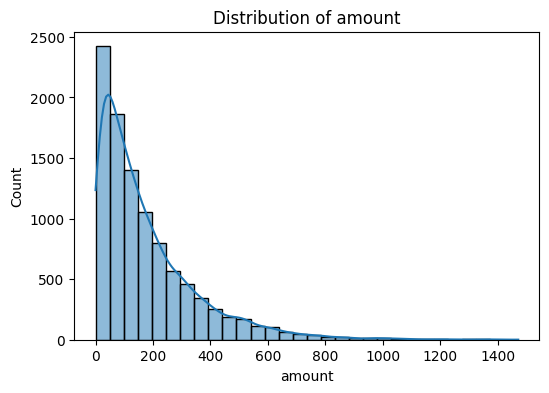

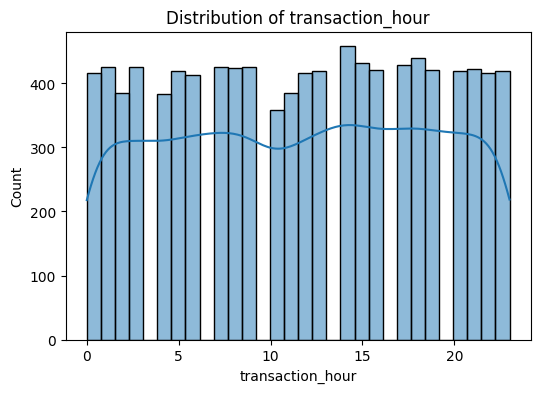

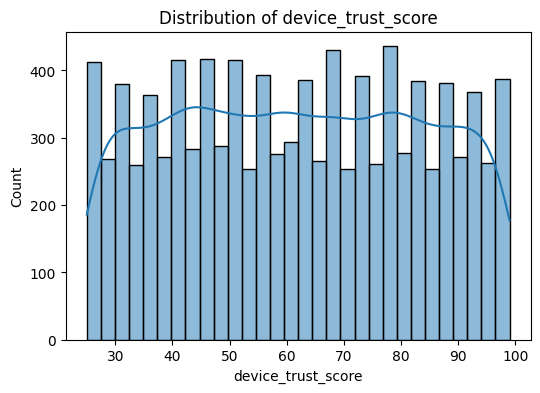

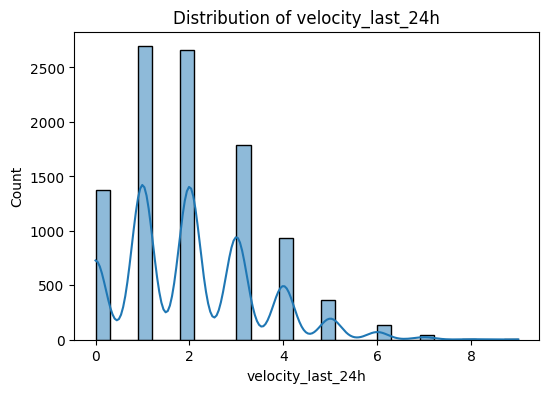

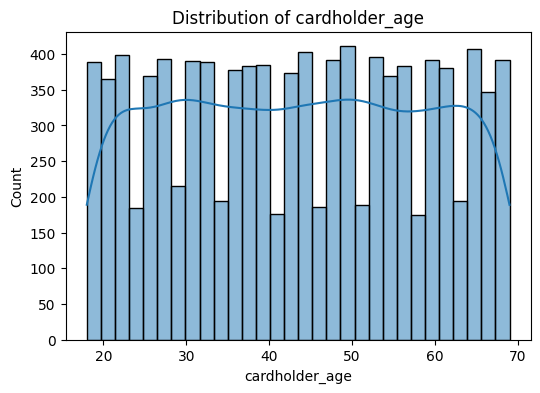

In [13]:
features_to_plot = [
    "amount",
    "transaction_hour",
    "device_trust_score",
    "velocity_last_24h",
    "cardholder_age"
]

for feature in features_to_plot:
    plt.figure(figsize=(6, 4))
    sns.histplot(data=df, x=feature, bins=30, kde=True)
    plt.title(f"Distribution of {feature}")
    plt.show()

### 5.3 Binary Feature Distribution

In [14]:
binary_features = [
    "foreign_transaction",
    "location_mismatch"
]

for feature in binary_features:
    print(f"\n{feature}")
    print(df[feature].value_counts())
    print(df[feature].value_counts(normalize=True) * 100)


foreign_transaction
foreign_transaction
0    9022
1     978
Name: count, dtype: int64
foreign_transaction
0    90.22
1     9.78
Name: proportion, dtype: float64

location_mismatch
location_mismatch
0    9143
1     857
Name: count, dtype: int64
location_mismatch
0    91.43
1     8.57
Name: proportion, dtype: float64


### 5.4 Merchant Category Distribution

In [15]:
print(df["merchant_category"].value_counts())

merchant_category
Food           2093
Clothing       2050
Travel         1990
Grocery        1944
Electronics    1923
Name: count, dtype: int64


In [16]:
print(
    df["merchant_category"].value_counts(normalize=True) * 100
)

merchant_category
Food           20.93
Clothing       20.50
Travel         19.90
Grocery        19.44
Electronics    19.23
Name: proportion, dtype: float64


## 6. Fraud vs Legitimate Analysis

### 6.1 Numerical Features vs Fraud

In [17]:
fraud_summary = df.groupby("is_fraud")[
    [
        "amount",
        "transaction_hour",
        "device_trust_score",
        "velocity_last_24h",
        "cardholder_age"
    ]
].mean()

fraud_summary

,amount,transaction_hour,device_trust_score,velocity_last_24h,cardholder_age
is_fraud,,,,,
0,175.333015,11.712154,62.165804,1.990557,43.469794
1,216.182980,3.841060,37.867550,3.205298,43.397351


### 6.2 Binary Features vs Fraud

In [18]:
binary_features = [
    "foreign_transaction",
    "location_mismatch"
]
for feature in binary_features:
    print(f"\n{feature}")    
    fraud_rate = df.groupby(feature)["is_fraud"].mean() * 100
    print(fraud_rate)


foreign_transaction
foreign_transaction
0    0.764797
1    8.384458
Name: is_fraud, dtype: float64

location_mismatch
location_mismatch
0    0.864049
1    8.401400
Name: is_fraud, dtype: float64


### 6.3 Merchant Category vs Fraud

In [19]:
merchant_fraud_rate = (
    df.groupby("merchant_category")["is_fraud"]
    .mean()
    .sort_values(ascending=False) * 100
)

merchant_fraud_rate

merchant_category
Grocery        2.006173
Food           1.672241
Travel         1.457286
Electronics    1.248050
Clothing       1.170732
Name: is_fraud, dtype: float64

### 6.4 Fraud Rate by Merchant Category

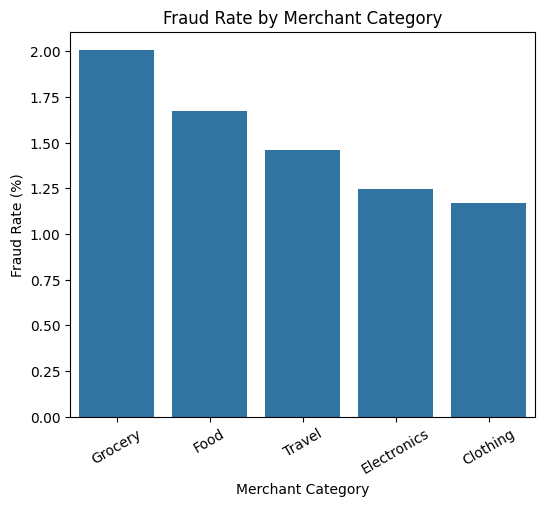

In [20]:
plt.figure(figsize=(6, 5))
sns.barplot(
    x=merchant_fraud_rate.index,
    y=merchant_fraud_rate.values
)

plt.xlabel("Merchant Category")
plt.ylabel("Fraud Rate (%)")
plt.title("Fraud Rate by Merchant Category")
plt.xticks(rotation=30)
plt.show()

### 6.5 Numerical Features vs Fraud

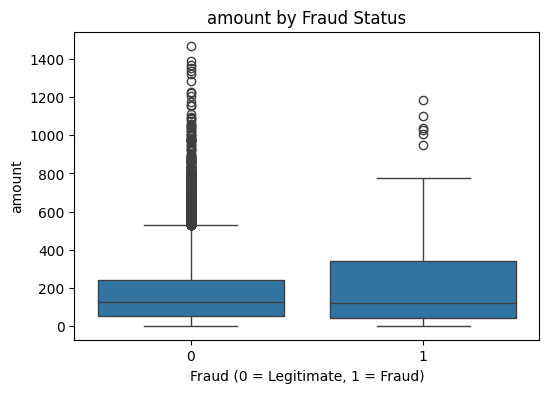

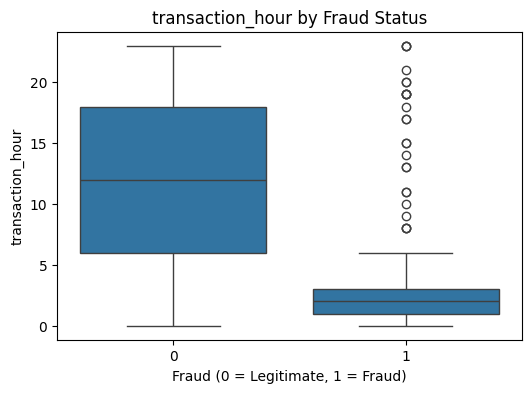

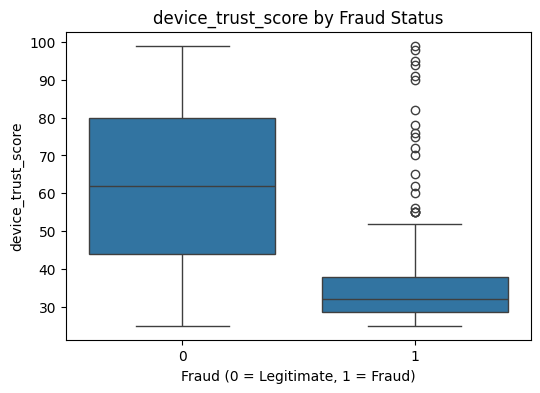

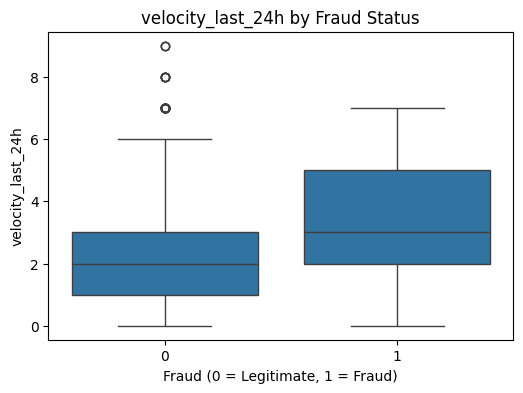

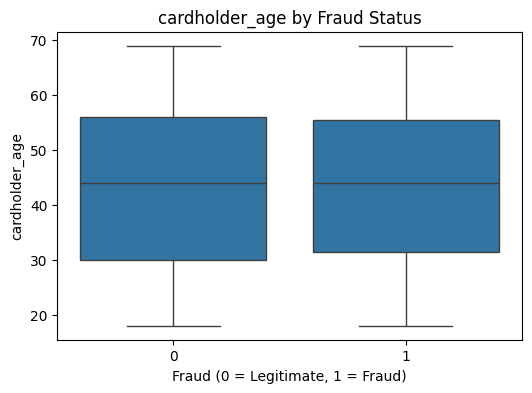

In [21]:
features_to_compare = [
    "amount",
    "transaction_hour",
    "device_trust_score",
    "velocity_last_24h",
    "cardholder_age"
]
for feature in features_to_compare:
    plt.figure(figsize=(6, 4))
    
    sns.boxplot(
        data=df,
        x="is_fraud",
        y=feature
    )
    
    plt.title(f"{feature} by Fraud Status")
    plt.xlabel("Fraud (0 = Legitimate, 1 = Fraud)")
    plt.ylabel(feature)
    plt.show()

## 7. Correlation Analysis

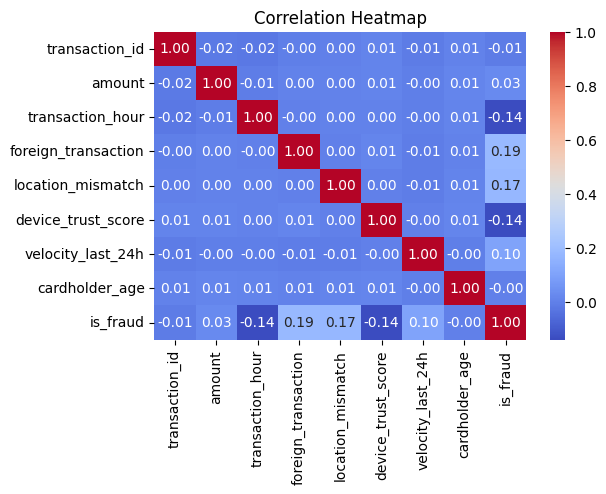

In [22]:
plt.figure(figsize=(6, 4))
correlation_matrix = df.select_dtypes(include=np.number).corr()

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

## 8. Feature Selection

In [23]:
X = df.drop(columns=["is_fraud", "transaction_id"])
y = df["is_fraud"]

print("Features:")
print(X.columns.tolist())

print("\nTarget:")
print(y.name)

print("\nX shape:", X.shape)
print("y shape:", y.shape)

Features:
['amount', 'transaction_hour', 'merchant_category', 'foreign_transaction', 'location_mismatch', 'device_trust_score', 'velocity_last_24h', 'cardholder_age']

Target:
is_fraud

X shape: (10000, 8)
y shape: (10000,)


## 9. Preprocessing

### 9.1 Train-Val-Test Split

In [24]:
from sklearn.model_selection import train_test_split
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("X_test:", X_test.shape)

print("y_train:", y_train.shape)
print("y_val:", y_val.shape)
print("y_test:", y_test.shape)

X_train: (7000, 8)
X_val: (1500, 8)
X_test: (1500, 8)
y_train: (7000,)
y_val: (1500,)
y_test: (1500,)


### 9.2 One Hot Encoding

In [25]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False
)

X_train_cat = encoder.fit_transform(
    X_train[["merchant_category"]]
)

X_val_cat = encoder.transform(
    X_val[["merchant_category"]]
)

X_test_cat = encoder.transform(
    X_test[["merchant_category"]]
)

print("Training categorical shape:", X_train_cat.shape)
print("Validation categorical shape:", X_val_cat.shape)
print("Test categorical shape:", X_test_cat.shape)

Training categorical shape: (7000, 5)
Validation categorical shape: (1500, 5)
Test categorical shape: (1500, 5)


### 9.2 Numerical Feature Scaling

In [26]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train_num = scaler.fit_transform(
    X_train[numerical_features]
)

X_val_num = scaler.transform(
    X_val[numerical_features]
)

print("X_train_num:", X_train_num.shape)
print("X_val_num:", X_val_num.shape)

X_train_num: (7000, 7)
X_val_num: (1500, 7)


In [27]:
X_train_processed = np.hstack([
    X_train_num,
    X_train_cat
])

X_val_processed = np.hstack([
    X_val_num,
    X_val_cat
])

print("X_train_processed:", X_train_processed.shape)
print("X_val_processed:", X_val_processed.shape)

X_train_processed: (7000, 12)
X_val_processed: (1500, 12)


In [28]:
print("Mean of scaled training numerical features:")
print(X_train_num.mean(axis=0))

print("\nStandard deviation of scaled training numerical features:")
print(X_train_num.std(axis=0))

Mean of scaled training numerical features:
[-4.66928083e-17  3.14668926e-17  8.62801893e-17  1.52259158e-18
 -2.79141789e-17 -1.14194368e-17 -4.06024420e-18]

Standard deviation of scaled training numerical features:
[1. 1. 1. 1. 1. 1. 1.]


In [29]:
print("Encoded categorical feature shape:")
print(X_train_cat.shape)

print("\nFirst 5 encoded rows:")
print(X_train_cat[:5])

Encoded categorical feature shape:
(7000, 5)

First 5 encoded rows:
[[0. 0. 1. 0. 0.]
 [0. 1. 0. 0. 0.]
 [1. 0. 0. 0. 0.]
 [0. 0. 1. 0. 0.]
 [0. 0. 1. 0. 0.]]


In [30]:
df.groupby("is_fraud")["device_trust_score"].describe()

,count,mean,std,min,25%,50%,75%,max
is_fraud,,,,,,,,
0,9849.0,62.165804,21.351099,25.0,44.0,62.0,80.0,99.0
1,151.0,37.867550,16.179277,25.0,28.5,32.0,38.0,99.0


In [31]:
df.groupby("is_fraud")["amount"].describe()

,count,mean,std,min,25%,50%,75%,max
is_fraud,,,,,,,,
0,9849.0,175.333015,173.986837,0.00,50.99,122.11,241.650,1471.04
1,151.0,216.182980,248.120467,0.11,41.53,118.94,341.695,1185.07


In [32]:
df["amount"].describe()

count    10000.000000
mean       175.949849
std        175.392827
min          0.000000
25%         50.905000
50%        122.095000
75%        242.480000
max       1471.040000
Name: amount, dtype: float64

In [33]:
df.groupby("is_fraud")["amount"].max()

is_fraud
0    1471.04
1    1185.07
Name: amount, dtype: float64